In [3]:
# =========================
# Synthetic Emergency & Disaster Dataset - Chennai Wards
# =========================

import pandas as pd
import numpy as np
import os

# --- 1. Parameters ---
num_wards = 155
weeks = 52   # Weekly data for 1 year (2026)
np.random.seed(42)  # For reproducibility

# Ward IDs and populations
ward_ids = [f"W{str(i+1).zfill(3)}" for i in range(num_wards)]
populations = np.random.randint(5000, 50000, size=num_wards)

# Disaster types
disaster_types = ['Flood', 'Cyclone', 'Fire']

# Season function
def get_season(week):
    if 1 <= week <= 16:
        return "Winter"
    elif 17 <= week <= 36:
        return "Summer"
    else:
        return "Monsoon"

# --- 2. Generate Data ---
data_rows = []
for week in range(1, weeks+1):
    season = get_season(week)
    date = pd.to_datetime(f'2026-W{str(week).zfill(2)}-1', format='%Y-W%W-%w')
    
    for ward_idx in range(num_wards):
        ward_id = ward_ids[ward_idx]
        population = populations[ward_idx]
        num_healthcare_facilities = np.random.randint(1, 10)
        distance_to_hospital = round(np.random.uniform(0.5, 15), 1)  # km
        past_event_count = np.random.randint(0, 6)
        
        # Randomly choose disaster type
        disaster_type = np.random.choice(disaster_types, p=[0.6,0.3,0.1])  # Floods more frequent
        
        # Severity index (0-1)
        if disaster_type == 'Flood':
            severity_index = round(np.random.uniform(0.2, 0.9),2)
        elif disaster_type == 'Cyclone':
            severity_index = round(np.random.uniform(0.3, 1.0),2)
        else:  # Fire
            severity_index = round(np.random.uniform(0.1, 0.7),2)
        
        # Calculate affected population
        affected_population = int(population * severity_index * np.random.uniform(0.3, 0.8))
        
        # Estimate emergency cases (e.g., 10-40% of affected)
        expected_emergency_cases = int(affected_population * np.random.uniform(0.1, 0.4))
        
        # Estimate response time (minutes)
        response_time_estimate = round(np.random.uniform(10, 60) + distance_to_hospital*2, 1)
        
        data_rows.append([
            date, ward_id, population, disaster_type, severity_index,
            affected_population, expected_emergency_cases, num_healthcare_facilities,
            distance_to_hospital, response_time_estimate, season, past_event_count
        ])

# --- 3. Create DataFrame ---
columns = [
    'date','ward_id','population_ward','disaster_type','severity_index',
    'affected_population','expected_emergency_cases','num_healthcare_facilities',
    'distance_to_hospital','response_time_estimate','season','past_event_count'
]

emergency_df = pd.DataFrame(data_rows, columns=columns)

# --- 4. Save CSV ---
os.makedirs("../data", exist_ok=True)
emergency_df.to_csv("../data/ward_emergency_demand_2026.csv", index=False)

# Preview
emergency_df.head()


,date,ward_id,population_ward,disaster_type,severity_index,affected_population,expected_emergency_cases,num_healthcare_facilities,distance_to_hospital,response_time_estimate,season,past_event_count
0,2026-01-05,W001,20795,Flood,0.36,3844,1327,7,13.5,80.0,Winter,5
1,2026-01-05,W002,5860,Flood,0.36,759,152,7,2.9,62.9,Winter,2
2,2026-01-05,W003,43158,Flood,0.25,4606,801,6,3.7,52.2,Winter,0
3,2026-01-05,W004,49732,Fire,0.26,10193,2276,3,4.9,21.5,Winter,0
4,2026-01-05,W005,16284,Flood,0.54,6971,1203,1,9.7,63.0,Winter,5


In [5]:
# =========================
# Emergency & Disaster Forecast + Resource Demand
# =========================

import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from joblib import Parallel, delayed
import os

# --- 1. Load synthetic emergency dataset ---
emergency_df = pd.read_csv("../data/ward_emergency_demand_2026.csv")
emergency_df['date'] = pd.to_datetime(emergency_df['date'])
emergency_df.rename(columns={'expected_emergency_cases':'y'}, inplace=True)
emergency_df['ds'] = emergency_df['date']

# --- 2. Forecast horizon ---
future_weeks = 12

# --- 3. Resource ratios ---
paramedic_ratio = 10   # 1 paramedic per 10 patients
ambulance_ratio = 20   # 1 ambulance per 20 patients

# --- 4. Forecast function for a ward ---
def forecast_ward_emergency(ward_id):
    try:
        ward_df = emergency_df[emergency_df['ward_id']==ward_id][['ds','y']].copy()
        model = ExponentialSmoothing(
            ward_df['y'], trend='add'
        )
        fit = model.fit()
        forecast_values = fit.forecast(future_weeks)
        
        # Create forecast dataframe
        future_dates = pd.date_range(
            start=ward_df['ds'].iloc[-1] + pd.Timedelta(weeks=1),
            periods=future_weeks, freq='W'
        )
        forecast_df = pd.DataFrame({
            'ds': future_dates,
            'ward_id': ward_id,
            'yhat': forecast_values.values
        })
        
        # Compute resource needs
        forecast_df['paramedics_needed'] = np.ceil(forecast_df['yhat']/paramedic_ratio)
        forecast_df['ambulances_needed'] = np.ceil(forecast_df['yhat']/ambulance_ratio)
        
        return forecast_df
    except Exception as e:
        print(f"Error in ward {ward_id}: {e}")
        return None

# --- 5. Run forecasts in parallel ---
all_forecasts = Parallel(n_jobs=4)(
    delayed(forecast_ward_emergency)(wid) for wid in emergency_df['ward_id'].unique()
)

all_forecasts = [f for f in all_forecasts if f is not None]

# --- 6. Concatenate and save ---
forecast_emergency_df = pd.concat(all_forecasts, ignore_index=True)

os.makedirs("../outputs", exist_ok=True)
forecast_emergency_df.to_csv("../outputs/ward_emergency_forecast.csv", index=False)
forecast_emergency_df.to_pickle("../outputs/ward_emergency_forecast.pkl")

# --- 7. Preview ---
forecast_emergency_df.head()


,ds,ward_id,yhat,paramedics_needed,ambulances_needed
0,2027-01-10,W001,1852.648224,186.0,93.0
1,2027-01-17,W001,1865.622298,187.0,94.0
2,2027-01-24,W001,1878.596371,188.0,94.0
3,2027-01-31,W001,1891.570445,190.0,95.0
4,2027-02-07,W001,1904.544519,191.0,96.0


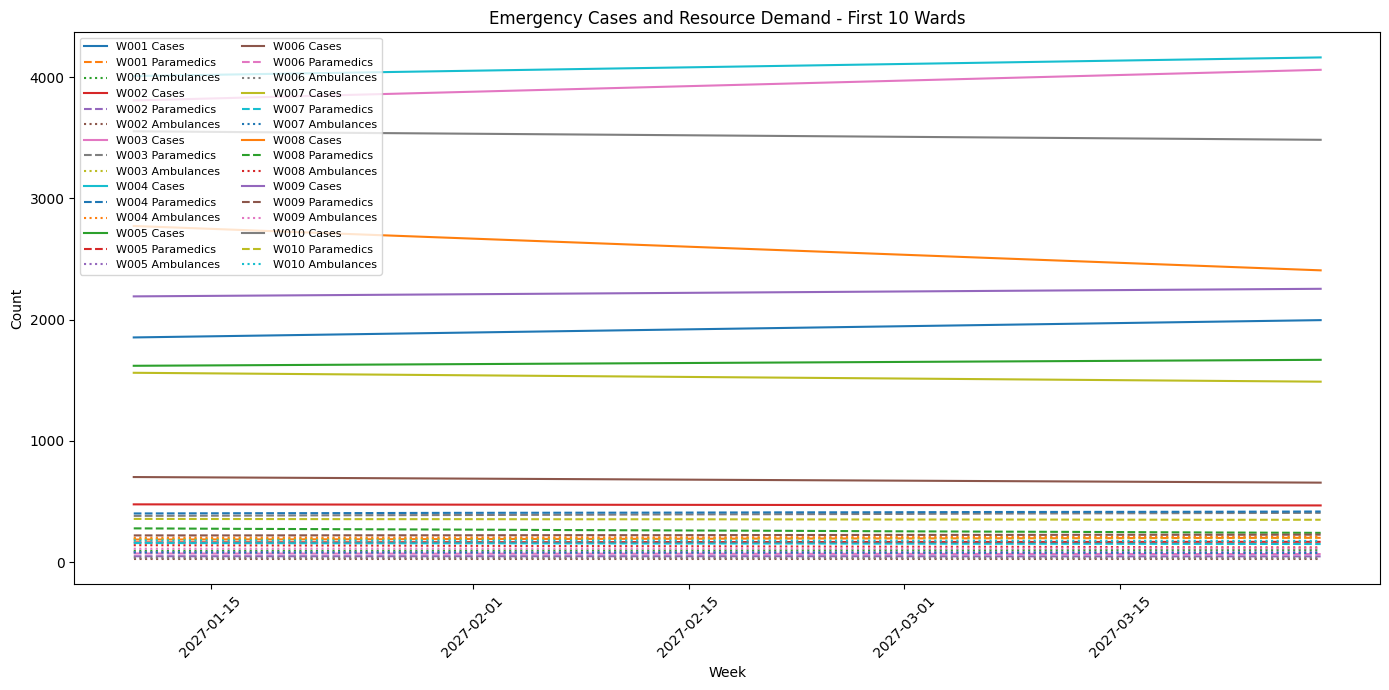

In [6]:
# =========================
# Plot Emergency Demand & Resources - First 10 Wards
# =========================

import matplotlib.pyplot as plt

wards_to_plot = forecast_emergency_df['ward_id'].unique()[:10]

plt.figure(figsize=(14,7))
for ward in wards_to_plot:
    ward_data = forecast_emergency_df[forecast_emergency_df['ward_id'] == ward]
    plt.plot(ward_data['ds'], ward_data['yhat'], label=f"{ward} Cases")
    plt.plot(ward_data['ds'], ward_data['paramedics_needed'], '--', label=f"{ward} Paramedics")
    plt.plot(ward_data['ds'], ward_data['ambulances_needed'], ':', label=f"{ward} Ambulances")

plt.xticks(rotation=45)
plt.xlabel("Week")
plt.ylabel("Count")
plt.title("Emergency Cases and Resource Demand - First 10 Wards")
plt.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

# --------------------------
# Load Emergency Data
# --------------------------
emergency_df = pd.read_csv("../data/ward_emergency_demand_2026.csv")
emergency_df['ds'] = pd.to_datetime(emergency_df['date'])
emergency_df.rename(columns={'expected_emergency_cases':'y'}, inplace=True)

# Parameters
test_weeks = 12
ward_ids = emergency_df['ward_id'].unique()

# Storage
all_forecasts = []
metrics_list = []

for ward_id in ward_ids:
    ward_data = emergency_df[emergency_df['ward_id']==ward_id][['ds','y']].copy()
    
    # Train/Test Split
    train_df = ward_data.iloc[:-test_weeks]
    test_df  = ward_data.iloc[-test_weeks:]
    
    # Fit Prophet
    model = Prophet(weekly_seasonality=True, yearly_seasonality=False)
    model.fit(train_df)
    
    # Forecast Test Period
    future = model.make_future_dataframe(periods=test_weeks, freq='W')
    forecast = model.predict(future)
    
    # Metrics
    y_true = test_df['y'].values
    y_pred = forecast['yhat'].values[-test_weeks:]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    metrics_list.append({
        'ward_id': ward_id,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    })
    
    # Optional: Forecast next 12 weeks
    future_forecast = model.make_future_dataframe(periods=12, freq='W')
    future_pred = model.predict(future_forecast)
    future_pred['ward_id'] = ward_id
    all_forecasts.append(future_pred[['ds','yhat','yhat_lower','yhat_upper','ward_id']])

# Combine
all_forecast_df = pd.concat(all_forecasts, ignore_index=True)
metrics_df = pd.DataFrame(metrics_list)

# Save
os.makedirs("../outputs", exist_ok=True)
all_forecast_df.to_csv("../outputs/ward_emergency_forecast_full.csv", index=False)
metrics_df.to_csv("../outputs/ward_emergency_metrics.csv", index=False)

print("Emergency & Disaster forecasts and metrics saved!")
metrics_df.head()


00:58:11 - cmdstanpy - INFO - Chain [1] start processing
00:58:11 - cmdstanpy - INFO - Chain [1] done processing
00:58:12 - cmdstanpy - INFO - Chain [1] start processing
00:58:12 - cmdstanpy - INFO - Chain [1] done processing
00:58:12 - cmdstanpy - INFO - Chain [1] start processing
00:58:13 - cmdstanpy - INFO - Chain [1] done processing
00:58:13 - cmdstanpy - INFO - Chain [1] start processing
00:58:13 - cmdstanpy - INFO - Chain [1] done processing
00:58:14 - cmdstanpy - INFO - Chain [1] start processing
00:58:14 - cmdstanpy - INFO - Chain [1] done processing
00:58:15 - cmdstanpy - INFO - Chain [1] start processing
00:58:15 - cmdstanpy - INFO - Chain [1] done processing
00:58:15 - cmdstanpy - INFO - Chain [1] start processing
00:58:16 - cmdstanpy - INFO - Chain [1] done processing
00:58:17 - cmdstanpy - INFO - Chain [1] start processing
00:58:17 - cmdstanpy - INFO - Chain [1] done processing
00:58:17 - cmdstanpy - INFO - Chain [1] start processing
00:58:18 - cmdstanpy - INFO - Chain [1]

Emergency & Disaster forecasts and metrics saved!


,ward_id,MAE,RMSE,MAPE
0,W001,1041.935269,1355.809839,52.415578
1,W002,864.602006,890.592651,162.654953
2,W003,2390.588299,2755.922037,62.923778
3,W004,2552.221525,3046.279193,60.197589
4,W005,898.231258,1121.964609,50.318305
